# Ridge Regression - Walk-Forward Validation

This notebook implements **Ridge Regression** with walk-forward validation for 24-hour ahead price forecasting.

## Approach
- **Model**: Ridge Regression (L2 regularization)
- **Validation**: Walk-forward with daily retraining
- **No Data Leakage**: Only use data available at prediction time
- **Production-ready**: Simulates real trading conditions

## Workflow
1. Load dataset with forecast features
2. Split: Initial training period (1 year) + walk-forward test
3. Each day:
   - Train on all historical data
   - Predict next 24 hours
   - Evaluate predictions
4. Calculate comprehensive metrics
5. Visualize results

In [6]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.models.walk_forward_validator import (
    walk_forward_validate,
    plot_walk_forward_results,
    save_walk_forward_results
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(" Imports successful")

 Imports successful


## 1. Load Dataset with Forecast Features

In [7]:
# Load the unified dataset
data_path = project_root / "data/dataset.csv"

df = pd.read_csv(data_path)
df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Dataset loaded: {len(df):,} rows x {len(df.columns)} columns")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"\nColumns: {list(df.columns)}")

df.head()

Dataset loaded: 28,405 rows x 47 columns
Date range: 2023-01-08 00:00:00 to 2026-04-06 23:00:00

Columns: ['datetime', 'price', 'load_mw', 'temperature_2m', 'wind_speed_10m', 'precipitation', 'shortwave_radiation', 'wind_production_mw', 'solar_production_mw', 'renewable_production_mw', 'net_load_mw', 'renewable_penetration_pct', 'hour', 'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year', 'month', 'quarter', 'year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_peak_hour', 'is_night', 'is_winter', 'is_summer', 'price_lag_24h', 'load_lag_24h', 'price_lag_48h', 'load_lag_48h', 'price_lag_72h', 'load_lag_72h', 'price_lag_168h', 'load_lag_168h', 'price_roll_mean_24h', 'price_roll_std_24h', 'load_roll_mean_24h', 'load_roll_std_24h', 'price_roll_mean_168h', 'price_roll_std_168h', 'load_roll_mean_168h', 'load_roll_std_168h']


,datetime,price,load_mw,temperature_2m,wind_speed_10m,precipitation,shortwave_radiation,wind_production_mw,solar_production_mw,renewable_production_mw,...,price_lag_168h,load_lag_168h,price_roll_mean_24h,price_roll_std_24h,load_roll_mean_24h,load_roll_std_24h,price_roll_mean_168h,price_roll_std_168h,load_roll_mean_168h,load_roll_std_168h
0,2023-01-08 00:00:00,13.21,48087.5,9.8,21.6,0.0,0.0,22000.0,0.0,22000.0,...,0.00,45377.0,85.464583,18.020052,50872.104167,3110.114275,102.413631,52.108852,52578.446429,6397.324317
1,2023-01-08 01:00:00,10.44,46711.5,9.6,19.6,0.2,0.0,22000.0,0.0,22000.0,...,-0.10,43874.0,81.951250,23.075979,50812.479167,3150.645905,102.492262,51.963150,52594.580357,6382.454286
2,2023-01-08 02:00:00,10.26,44280.5,9.6,19.0,0.1,0.0,22000.0,0.0,22000.0,...,-1.33,40789.0,78.295000,27.007925,50752.000000,3216.949716,102.555000,51.844771,52611.470238,6362.963514
3,2023-01-08 03:00:00,4.16,42818.5,9.6,19.5,0.0,0.0,22000.0,0.0,22000.0,...,-4.08,38843.5,74.767917,30.094764,50694.895833,3321.886944,102.623988,51.713252,52632.252976,6329.732889
4,2023-01-08 04:00:00,4.16,43000.5,9.5,19.8,0.0,0.0,22000.0,0.0,22000.0,...,-4.16,38174.0,71.689583,33.348179,50629.083333,3464.642646,102.673036,51.615257,52655.913690,6285.153864


## 2. Load Feature List (Excluding Target and Metadata)

In [8]:
# Load pre-defined feature columns (no data leakage)
features_path = project_root / "data/features.txt"

with open(features_path, 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(f"Number of features: {len(feature_cols)}")
print(f"\nFeature categories:")
print(f"  - Weather: {len([c for c in feature_cols if any(x in c for x in ['temperature', 'wind_speed', 'precipitation', 'shortwave'])])}")
print(f"  - Renewable production: {len([c for c in feature_cols if any(x in c for x in ['wind_production', 'solar_production', 'renewable', 'net_load'])])}")
print(f"  - Historical lags: {len([c for c in feature_cols if 'lag' in c])}")
print(f"  - Rolling stats: {len([c for c in feature_cols if 'roll' in c])}")
print(f"  - Calendar: {len([c for c in feature_cols if any(x in c for x in ['hour', 'day', 'month', 'sin', 'cos', 'weekend', 'peak', 'winter', 'summer'])])}")
print(f"\nFeatures: {feature_cols}")

Number of features: 44

Feature categories:
  - Weather: 4
  - Renewable production: 5
  - Historical lags: 8
  - Rolling stats: 8
  - Calendar: 15

Features: ['temperature_2m', 'wind_speed_10m', 'precipitation', 'shortwave_radiation', 'wind_production_mw', 'solar_production_mw', 'renewable_production_mw', 'net_load_mw', 'renewable_penetration_pct', 'hour', 'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year', 'month', 'quarter', 'year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_peak_hour', 'is_night', 'is_winter', 'is_summer', 'price_lag_24h', 'load_lag_24h', 'price_lag_48h', 'load_lag_48h', 'price_lag_72h', 'load_lag_72h', 'price_lag_168h', 'load_lag_168h', 'price_roll_mean_24h', 'price_roll_std_24h', 'load_roll_mean_24h', 'load_roll_std_24h', 'price_roll_mean_168h', 'price_roll_std_168h', 'load_roll_mean_168h', 'load_roll_std_168h']


## 3. Create Ridge Regression Model with Preprocessing

Ridge regression requires feature scaling for optimal performance.

In [9]:
from sklearn.pipeline import Pipeline

# Create Ridge model with preprocessing pipeline
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features
    ('ridge', Ridge(
        alpha=1.0,  # Regularization strength
        fit_intercept=True,
        max_iter=1000,
        random_state=42
    ))
])

print(" Ridge Regression pipeline created")
print(f"\nModel configuration:")
print(f"  - Regularization (alpha): 1.0")
print(f"  - Solver: Automatic (cholesky/lsqr/sag)")
print(f"  - Feature scaling: StandardScaler")
print(f"\nRidge Regression characteristics:")
print(f"   Fast training and prediction")
print(f"   Good baseline model")
print(f"   Handles multicollinearity well")
print(f"   L2 regularization prevents overfitting")
print(f"    Assumes linear relationships")

 Ridge Regression pipeline created

Model configuration:
  - Regularization (alpha): 1.0
  - Solver: Automatic (cholesky/lsqr/sag)
  - Feature scaling: StandardScaler

Ridge Regression characteristics:
   Fast training and prediction
   Good baseline model
   Handles multicollinearity well
   L2 regularization prevents overfitting
  ️  Assumes linear relationships


## 4. Walk-Forward Validation

This simulates real trading conditions:
- Train on 1 year of historical data initially
- Each day: retrain with new data, predict next 24 hours
- Expanding window (use all past data)
- **NO DATA LEAKAGE**: Only use features available at prediction time

In [10]:
# Walk-forward validation parameters
INITIAL_TRAIN_DAYS = 365  # 1 year of initial training data
FORECAST_HORIZON_HOURS = 24  # Predict 24 hours ahead
RETRAIN_FREQUENCY_DAYS = 1  # Retrain every day (realistic for trading)

print("Starting walk-forward validation...")
print(f"This may take a few minutes as we retrain the model daily.\n")

predictions_df, metrics, daily_metrics = walk_forward_validate(
    df=df,
    model=ridge_pipeline,
    feature_cols=feature_cols,
    target_col='price',
    initial_train_days=INITIAL_TRAIN_DAYS,
    forecast_horizon_hours=FORECAST_HORIZON_HOURS,
    retrain_frequency_days=RETRAIN_FREQUENCY_DAYS,
    expanding_window=True,  # Use all past data
    verbose=True
)

print("\n Walk-forward validation completed!")

Starting walk-forward validation...
This may take a few minutes as we retrain the model daily.


 Walk-forward validation completed!


## 5. Overall Metrics

In [11]:
print("="*80)
print("RIDGE REGRESSION - OVERALL METRICS")
print("="*80)

print(f"\n Prediction Statistics:")
print(f"  Total predictions: {metrics['n_predictions']:,} hours")
print(f"  Test period: {predictions_df['datetime'].min()} to {predictions_df['datetime'].max()}")
print(f"  Duration: {metrics['coverage_hours']:.0f} hours ({metrics['coverage_hours']/24:.1f} days)")

print(f"\n Accuracy Metrics:")
print(f"  MAE (Mean Absolute Error):     {metrics['mae']:8.2f} EUR/MWh")
print(f"  RMSE (Root Mean Squared Error): {metrics['rmse']:8.2f} EUR/MWh")
print(f"  MAPE (Mean Absolute % Error):   {metrics['mape']:8.2f}%")
print(f"  R² Score:                       {metrics['r2']:8.3f}")

print(f"\n Directional Accuracy:")
print(f"  Direction accuracy: {metrics['direction_accuracy']:.2f}%")
print(f"  (Did we predict price increase/decrease correctly?)")

print(f"\n  Bias Analysis:")
print(f"  Bias (systematic error):  {metrics['bias']:8.2f} EUR/MWh")
print(f"  Error std deviation:      {metrics['error_std']:8.2f} EUR/MWh")

print(f"\n Error Distribution:")
print(f"  5th percentile (underpredict): {metrics['error_q05']:8.2f} EUR/MWh")
print(f"  95th percentile (overpredict): {metrics['error_q95']:8.2f} EUR/MWh")
print(f"  Max overprediction:            {metrics['max_overpredict']:8.2f} EUR/MWh")
print(f"  Max underprediction:           {metrics['max_underpredict']:8.2f} EUR/MWh")

# Create metrics DataFrame for easy viewing
metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ['Value']
metrics_df

RIDGE REGRESSION - OVERALL METRICS

 Prediction Statistics:
  Total predictions: 19,056 hours
  Test period: 2024-01-09 00:00:00 to 2026-04-06 23:00:00
  Duration: 19655 hours (819.0 days)

 Accuracy Metrics:
  MAE (Mean Absolute Error):        14.77 EUR/MWh
  RMSE (Root Mean Squared Error):    19.62 EUR/MWh
  MAPE (Mean Absolute % Error):      47.57%
  R² Score:                          0.806

 Directional Accuracy:
  Direction accuracy: 78.50%
  (Did we predict price increase/decrease correctly?)

️  Bias Analysis:
  Bias (systematic error):     -1.56 EUR/MWh
  Error std deviation:         19.56 EUR/MWh

 Error Distribution:
  5th percentile (underpredict):   -33.16 EUR/MWh
  95th percentile (overpredict):    28.97 EUR/MWh
  Max overprediction:              101.24 EUR/MWh
  Max underprediction:            -269.06 EUR/MWh


,Value
mae,14.774408
rmse,19.618952
mape,47.573799
r2,0.806332
direction_accuracy,78.504330
bias,-1.555064
error_std,19.557225
error_q05,-33.156957
error_q95,28.966167
max_overpredict,101.244020


## 6. Visualize Results

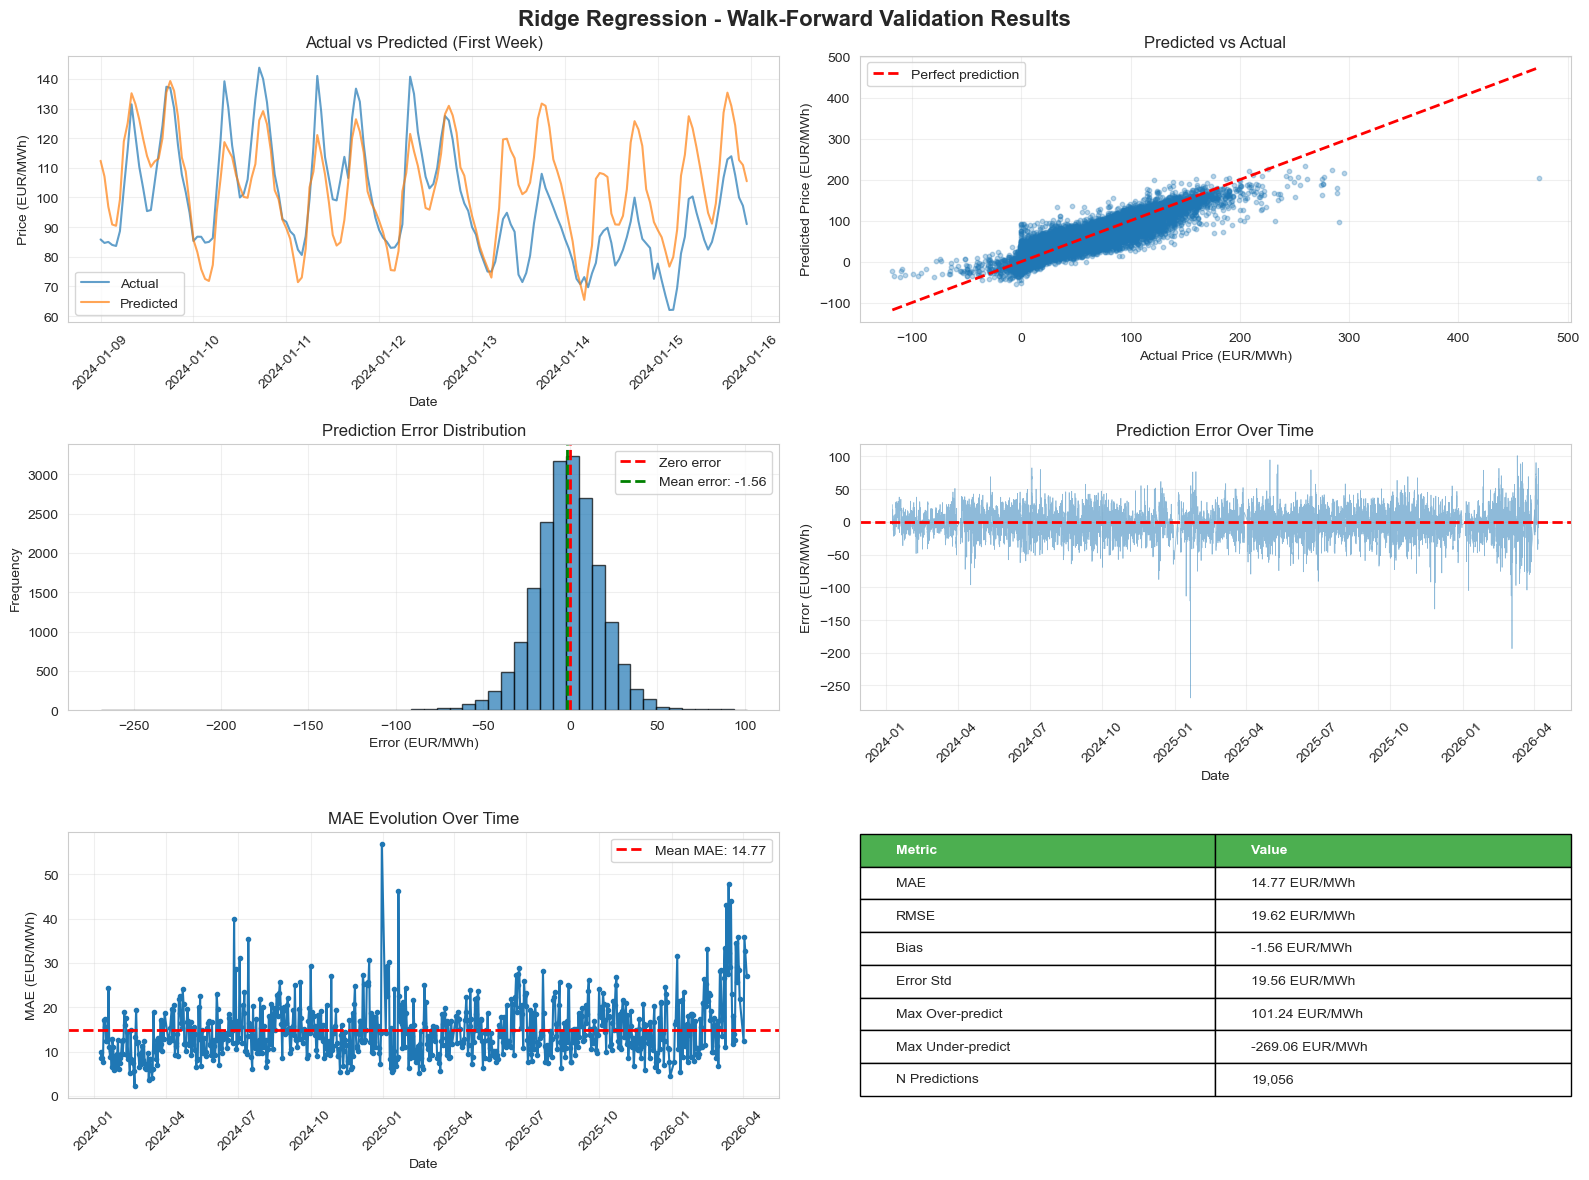


 Figure saved to: c:\Users\arnov\Desktop\energy-demand-forecast\research\reports\ridge_walk_forward_results.png


In [12]:
# Generate comprehensive plots
fig = plot_walk_forward_results(
    predictions_df=predictions_df,
    daily_metrics=daily_metrics,
    model_name="Ridge Regression"
)

plt.show()

# Save figure
output_dir = project_root / "research_notebooks/reports"
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "ridge_walk_forward_results.png", dpi=150, bbox_inches='tight')
print(f"\n Figure saved to: {output_dir / 'ridge_walk_forward_results.png'}")

## 7. Analyze Predictions by Hour of Day

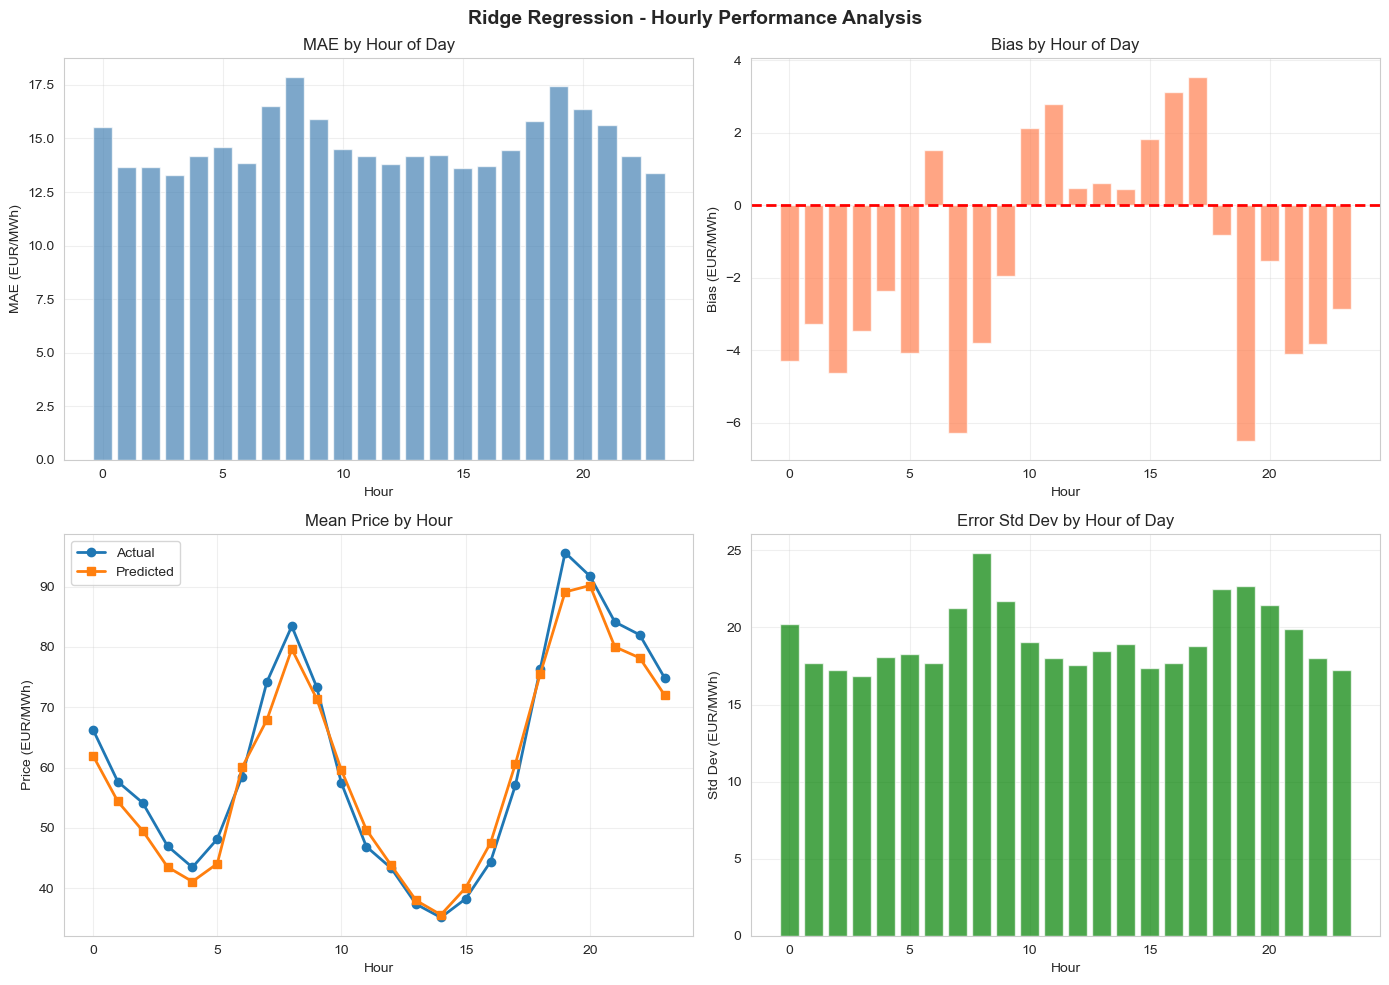


 Hourly Metrics Summary:
        MAE  Bias  Error_Std  Actual_Mean  Predicted_Mean
hour                                                     
0     15.54 -4.31      20.24        66.31           62.00
1     13.68 -3.28      17.72        57.67           54.39
2     13.67 -4.63      17.22        54.17           49.54
3     13.31 -3.47      16.88        47.01           43.54
4     14.16 -2.36      18.08        43.48           41.12
5     14.59 -4.07      18.25        48.16           44.08
6     13.84  1.51      17.71        58.53           60.04
7     16.51 -6.28      21.28        74.21           67.93
8     17.85 -3.79      24.80        83.44           79.65
9     15.89 -1.95      21.71        73.38           71.44
10    14.51  2.14      19.04        57.40           59.55
11    14.19  2.80      18.05        46.92           49.72
12    13.82  0.47      17.56        43.34           43.81
13    14.17  0.62      18.50        37.38           38.00
14    14.25  0.46      18.90        35.17     

In [13]:
# Add hour to predictions
predictions_df['hour'] = pd.to_datetime(predictions_df['datetime']).dt.hour

# Calculate metrics by hour
hourly_metrics = predictions_df.groupby('hour').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'actual': 'mean',
    'predicted': 'mean'
}).round(2)

hourly_metrics.columns = ['MAE', 'Bias', 'Error_Std', 'Actual_Mean', 'Predicted_Mean']

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ridge Regression - Hourly Performance Analysis', fontsize=14, fontweight='bold')

# MAE by hour
axes[0, 0].bar(hourly_metrics.index, hourly_metrics['MAE'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('MAE by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('MAE (EUR/MWh)')
axes[0, 0].grid(True, alpha=0.3)

# Bias by hour
axes[0, 1].bar(hourly_metrics.index, hourly_metrics['Bias'], color='coral', alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Bias by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Bias (EUR/MWh)')
axes[0, 1].grid(True, alpha=0.3)

# Actual vs Predicted mean by hour
axes[1, 0].plot(hourly_metrics.index, hourly_metrics['Actual_Mean'], marker='o', label='Actual', linewidth=2)
axes[1, 0].plot(hourly_metrics.index, hourly_metrics['Predicted_Mean'], marker='s', label='Predicted', linewidth=2)
axes[1, 0].set_title('Mean Price by Hour')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Price (EUR/MWh)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Error std by hour
axes[1, 1].bar(hourly_metrics.index, hourly_metrics['Error_Std'], color='green', alpha=0.7)
axes[1, 1].set_title('Error Std Dev by Hour of Day')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Std Dev (EUR/MWh)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Hourly Metrics Summary:")
print(hourly_metrics)

## 8. Daily Metrics Evolution

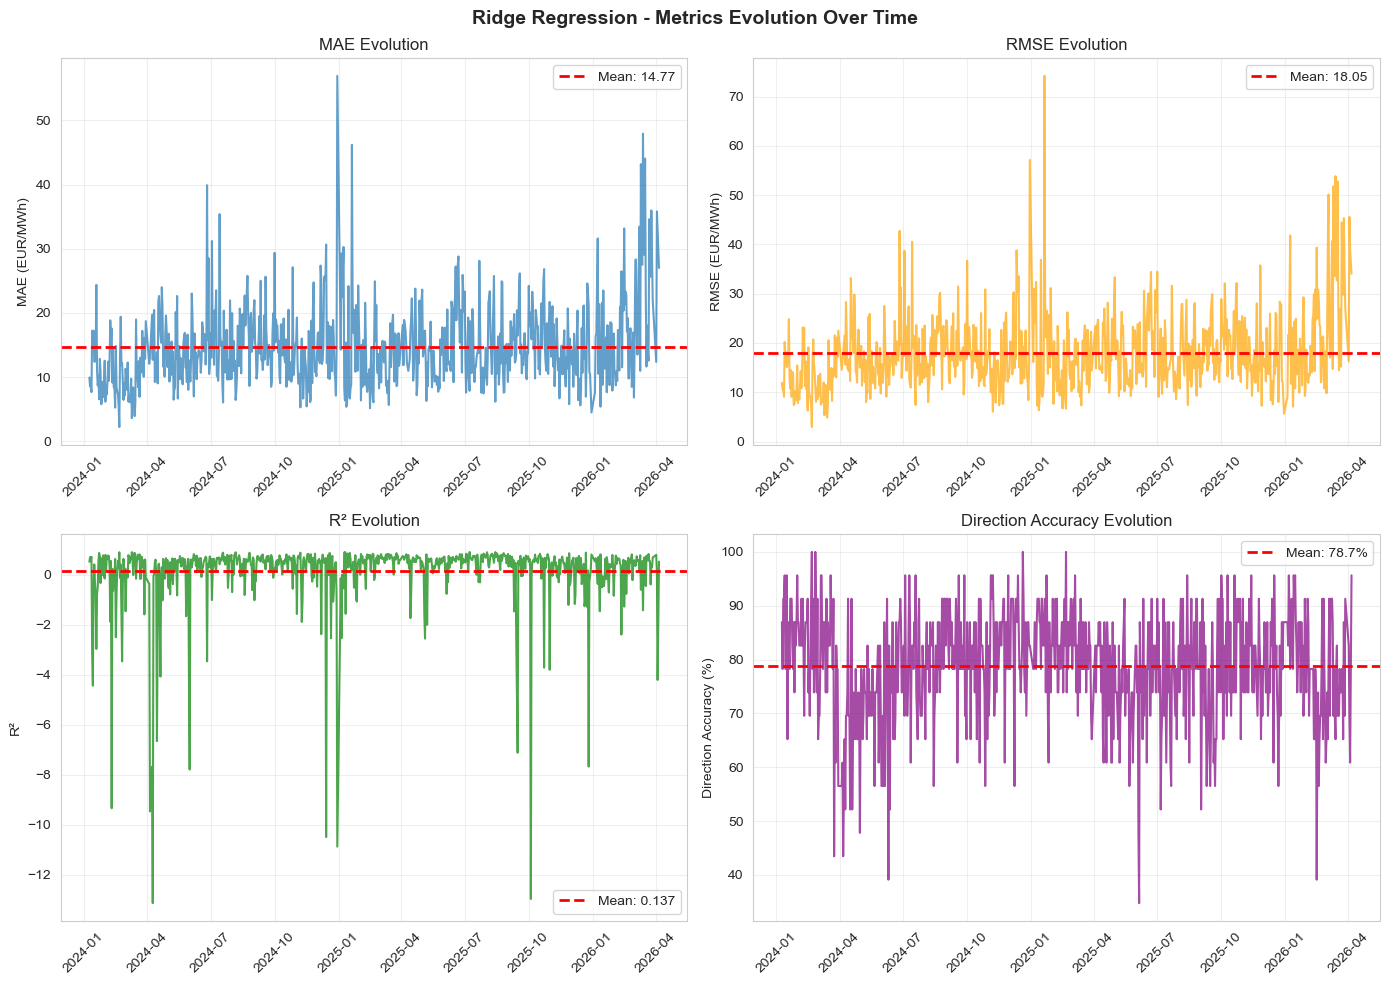


 Daily Metrics Statistics:
              mae        rmse          r2  direction_accuracy
count  794.000000  794.000000  794.000000          794.000000
mean    14.774408   18.054715    0.136534           78.748220
std      6.335048    7.681462    1.418014           10.026252
min      2.238095    2.938774  -13.132511           34.782609
25%     10.522022   12.914619    0.156101           73.913043
50%     13.635317   16.491989    0.529640           78.260870
75%     18.008940   22.056385    0.676385           86.956522
max     56.927111   74.194405    0.909394          100.000000


In [14]:
# Convert to DataFrame
daily_metrics_df = pd.DataFrame(daily_metrics)

# Plot evolution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ridge Regression - Metrics Evolution Over Time', fontsize=14, fontweight='bold')

# MAE
axes[0, 0].plot(daily_metrics_df['datetime'], daily_metrics_df['mae'], linewidth=1.5, alpha=0.7)
axes[0, 0].axhline(daily_metrics_df['mae'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_metrics_df['mae'].mean():.2f}")
axes[0, 0].set_title('MAE Evolution')
axes[0, 0].set_ylabel('MAE (EUR/MWh)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# RMSE
axes[0, 1].plot(daily_metrics_df['datetime'], daily_metrics_df['rmse'], linewidth=1.5, alpha=0.7, color='orange')
axes[0, 1].axhline(daily_metrics_df['rmse'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_metrics_df['rmse'].mean():.2f}")
axes[0, 1].set_title('RMSE Evolution')
axes[0, 1].set_ylabel('RMSE (EUR/MWh)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# R²
axes[1, 0].plot(daily_metrics_df['datetime'], daily_metrics_df['r2'], linewidth=1.5, alpha=0.7, color='green')
axes[1, 0].axhline(daily_metrics_df['r2'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_metrics_df['r2'].mean():.3f}")
axes[1, 0].set_title('R² Evolution')
axes[1, 0].set_ylabel('R²')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Direction Accuracy
axes[1, 1].plot(daily_metrics_df['datetime'], daily_metrics_df['direction_accuracy'], linewidth=1.5, alpha=0.7, color='purple')
axes[1, 1].axhline(daily_metrics_df['direction_accuracy'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_metrics_df['direction_accuracy'].mean():.1f}%")
axes[1, 1].set_title('Direction Accuracy Evolution')
axes[1, 1].set_ylabel('Direction Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n Daily Metrics Statistics:")
print(daily_metrics_df[['mae', 'rmse', 'r2', 'direction_accuracy']].describe())

## 9. Save Results

In [15]:
# Save all results
save_walk_forward_results(
    predictions_df=predictions_df,
    metrics=metrics,
    daily_metrics=daily_metrics,
    model_name="ridge",
    output_dir=str(project_root / "research_notebooks/reports")
)

print("\n All results saved to research_notebooks/reports/")
print("   - ridge_predictions.csv")
print("   - ridge_daily_metrics.csv")
print("   - ridge_metrics.txt")


 All results saved to research/reports/
   - ridge_predictions.csv
   - ridge_daily_metrics.csv
   - ridge_metrics.txt


## 10. Summary & Insights

### Ridge Regression Performance

**Strengths:**
-  Fast training (retrains in seconds)
-  Stable predictions
-  Good baseline model
-  Handles multicollinearity well

**Limitations:**
-  Linear model - may miss non-linear patterns
-  Cannot capture complex interactions between features
-  May underperform during extreme events

### Key Takeaways

1. **MAE** shows average prediction error in EUR/MWh
2. **Direction accuracy** is crucial for trading (predict up/down)
3. **Bias** indicates systematic over/under prediction
4. **Daily retraining** ensures model stays up-to-date
